## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from googleapiclient import discovery
import time
import re
import os
from langdetect import detect
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [269]:
trump = pd.read_csv('trump_tweets.csv')
obama = pd.read_csv('Tweets-BarackObama.csv')
musk = pd.read_csv('elon musk full tweet history/all_musk_posts_2010-06-04_2025-03-21.csv')

/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/3464644449.py:3: DtypeWarning: Columns (11,16,17,18,19,23) have mixed types. Specify dtype option on import or set low_memory=False.
  musk_orig = pd.read_csv('elon musk full tweet history/all_musk_posts_2010-06-04_2025-03-21.csv')


## Loading in & Cleaning Data

In [2]:
# Load in the data
trump = pd.read_csv('trump_tweets.csv')
obama = pd.read_csv('Tweets-BarackObama.csv')
musk = pd.read_csv('elon musk full tweet history/all_musk_posts_2010-06-04_2025-03-21.csv')


def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"^RT\s+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_tweet_df(df, text_col, date_col, user_handle, is_retweet_col=None, date_format=None,
                   min_length=10, max_length=280):
    df = df.dropna(subset=[text_col])
    
    # Rename to standardized names
    df = df.rename(columns={text_col: 'text', date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'], format=date_format) if date_format else pd.to_datetime(df['date'])

    # Clean text
    df['clean_text'] = df['text'].apply(clean_text)

    # Filter out duplicates
    df = df.drop_duplicates(subset='clean_text')

    # Filter by length
    df = df[df['clean_text'].str.len().between(min_length, max_length)]

    # Mentions and hashtags
    df['accounts_mentioned'] = df['text'].str.findall(r'@([a-zA-Z0-9_]+)').apply(
        lambda mentions: [m for m in mentions if m.lower() != user_handle.lower()]
    )
    df['hashtags'] = df['text'].str.findall(r'#([a-zA-Z0-9_]+)')

    # Retweet filtering
    if is_retweet_col:
        retweets = df[(df[is_retweet_col] == True) | df['text'].str.startswith('RT ')]
        df = df[~((df[is_retweet_col] == True) | df['text'].str.startswith('RT '))]
        df.drop(columns=[is_retweet_col], inplace=True)
    else:
        retweets = df[df['text'].str.startswith('RT')]
        df = df[~df['text'].str.startswith('RT')]

    # Sort by date
    df = df.sort_values('date')

    return df, retweets


# Trump
trump, trump_retweets = clean_tweet_df(
    trump,
    text_col='text',
    date_col='date',
    user_handle='realdonaldtrump'
)
trump = trump[['clean_text', 'text', 'date', 'accounts_mentioned', 'hashtags']]

# Obama
obama, obama_retweets = clean_tweet_df(
    obama,
    text_col='Tweet-text',
    date_col='Date',
    user_handle='barackobama',
    date_format='%Y/%m/%d_%H:%M'
)

# Musk
musk, musk_retweets = clean_tweet_df(
    musk,
    text_col='fullText',
    date_col='createdAt',
    user_handle='elonmusk',
    is_retweet_col='isRetweet'
)

# trump.to_csv('trump_cleaned.csv', index=False)
# musk.to_csv('musk_cleaned.csv', index=False)
# obama.to_csv('obama_cleaned.csv', index=False)

/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/3044778583.py:4: DtypeWarning: Columns (11,16,17,18,19,23) have mixed types. Specify dtype option on import or set low_memory=False.
  musk = pd.read_csv('elon musk full tweet history/all_musk_posts_2010-06-04_2025-03-21.csv')


## Data Scoring & Exploration

In [3]:
# Set up Perspective API client
API_KEY = 'INSERT-KEY-HERE'
client = discovery.build(
    "commentanalyzer",
    "v1alpha1",
    developerKey=API_KEY,
    discoveryServiceUrl="https://commentanalyzer.googleapis.com/$discovery/rest?version=v1alpha1",
    static_discovery=False,
)

def get_toxicity_score(text):
    analyze_request = {
        'comment': {'text': text},
        'requestedAttributes': {'TOXICITY': {}, 'SEVERE_TOXICITY': {}, 'INSULT': {}, 'IDENTITY_ATTACK': {}}
    }
    try:
        response = client.comments().analyze(body=analyze_request).execute()
        return {attr: response['attributeScores'][attr]['summaryScore']['value']
                for attr in response['attributeScores']}
    except Exception as e:
        print("Error:", e)
        return None

In [4]:
# --- Utility Functions --- #

def detect_language(text):
    try:
        return detect(text)
    except Exception as e:
        print(f"Error detecting language: {e}")
        return None

def save_results(chunk, results_list, master_df, output_file):
    """Save chunk to CSV and reset list."""
    chunk_df = pd.DataFrame(results_list)
    master_df = pd.concat([master_df, chunk_df], ignore_index=True)
    master_df.to_csv(output_file, index=False)
    return [], master_df

def score_dataframe(df, output_file, text_col='text', clean_col=None, lang_filter=False):
    """
    Score tweets in a DataFrame using get_toxicity_score().
    
    Args:
        df: DataFrame with tweet data
        output_file: Path to save results
        text_col: Column containing original tweet text
        clean_col: Optional column for cleaned text
        lang_filter: If True, filter non-English tweets using langdetect on `clean_col`

    Returns:
        Final DataFrame with scores
    """
    if os.path.exists(output_file):
        existing_df = pd.read_csv(output_file)
        done_texts = set(existing_df[clean_col or text_col])
        print(f"Resuming... {len(done_texts)} tweets already scored.")
    else:
        existing_df = pd.DataFrame()
        done_texts = set()

    if lang_filter:
        df['language'] = df[clean_col].apply(detect_language)
        df = df[df['language'] == 'en']

    results = []
    total_to_process = sum(row[clean_col or text_col] not in done_texts for _, row in df.iterrows())
    progress_bar = tqdm(df.iterrows(), total=total_to_process, desc=f"Scoring {output_file}")

    for _, row in progress_bar:
        ref_text = row[clean_col or text_col]
        if ref_text in done_texts:
            continue

        scores = get_toxicity_score(ref_text)
        if scores:
            result = {
                'date': row['date'],
                'text': row['text'],
                clean_col: row[clean_col] if clean_col else None,
                **scores
            }
            results.append(result)

        if len(results) >= 100:
            results, existing_df = save_results(results, results, existing_df, output_file)
            progress_bar.set_postfix(saved=len(existing_df))

        time.sleep(1.1)  # Respect rate limit

    if results:
        _, existing_df = save_results(results, results, existing_df, output_file)
        print(f"Final save complete with {len(existing_df)} tweets processed.")

    progress_bar.close()
    return existing_df


# --- Dataset-Specific Execution --- #

# Musk
musk_results_df = score_dataframe(musk, output_file="musk_scored_progress.csv")
#musk_results_df = pd.read_csv("musk_scored_progress.csv")

# Trump
trump_results_df = score_dataframe(trump, output_file="trump_scored_progress.csv")
#trump_results_df = pd.read_csv("trump_scored_progress.csv")

# Obama
obama_results_df = score_dataframe(obama, output_file="obama_scored_progress.csv")
#obama_results_df = pd.read_csv("obama_scored_progress.csv")


## Analysis

/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/4187017981.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = musk_results_df.resample('M')[['TOXICITY', 'SEVERE_TOXICITY', 'INSULT', 'IDENTITY_ATTACK']].mean()


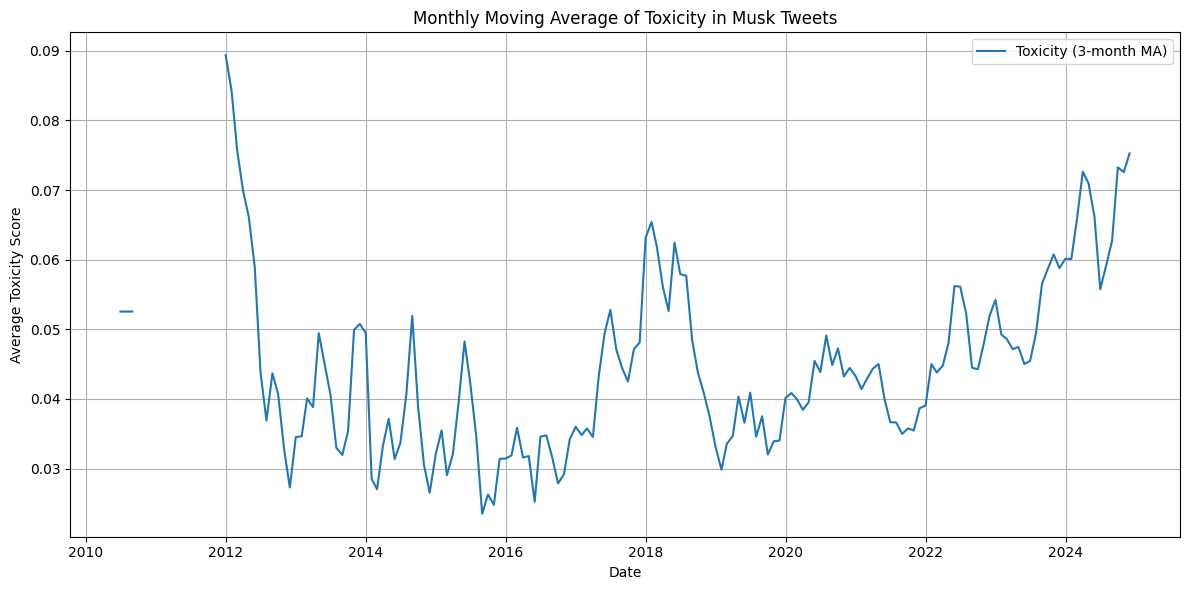

In [5]:
# Convert date column to datetime and set as index
#musk_results_df = pd.read_csv('musk_scored_progress.csv')
#muskfinal = musk_results_df.copy().reset_index()
musk_results_df['date'] = pd.to_datetime(musk_results_df['date'], errors='coerce')
musk_results_df.set_index('date', inplace=True)

# Resample monthly and compute moving average
monthly_avg = musk_results_df.resample('M')[['TOXICITY', 'SEVERE_TOXICITY', 'INSULT', 'IDENTITY_ATTACK']].mean()
rolling_avg = monthly_avg.rolling(window=3, min_periods=1).mean()


# Plot monthly rolling averages
plt.figure(figsize=(12, 6))
plt.plot(rolling_avg.index, rolling_avg['TOXICITY'], label='Toxicity (3-month MA)')
plt.title("Monthly Moving Average of Toxicity in Musk Tweets")
plt.xlabel("Date")
plt.ylabel("Average Toxicity Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [275]:
def plot_tweet_analysis(df, person_name="Musk", start_date="2018-05-01", end_date=None, tweet_threshold=100):
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error
    import numpy as np
    import pandas as pd
    from scipy.stats import pearsonr

    # --- Ensure datetime index ---
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'date' not in df.columns:
            raise KeyError("The DataFrame must have a datetime index or a 'date' column.")
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.set_index('date')

    # --- Prepare ---
    df['month'] = df.index.to_period('M').to_timestamp()
    
    # Apply date range mask
    mask = (df.index >= start_date)
    if end_date:
        mask &= (df.index <= end_date)
    df_filtered = df[mask]

    # --- Plot 1: Monthly Tweet Count ---
    monthly_counts = df_filtered.groupby('month').size()
    colors = ['red' if count > tweet_threshold else 'blue' for count in monthly_counts]

    plt.figure(figsize=(16, 6))
    plt.bar(monthly_counts.index, monthly_counts.values, color=colors, width=20)
    plt.axhline(tweet_threshold, color='gray', linestyle='--', linewidth=1)
    if len(monthly_counts.index) > 5:
        plt.text(monthly_counts.index[5], tweet_threshold + 10, f'Threshold: {tweet_threshold} Tweets', color='gray')
    plt.title(f"Number of Tweets per Month - {person_name}")
    plt.xlabel("Month")
    plt.ylabel("Number of Tweets")
    plt.grid(axis='y')
    ax = plt.gca()
    ax.set_xticks(monthly_counts.index[::3])
    ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_counts.index[::3]], rotation=70)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Monthly Rolling Averages of Toxicity ---
    monthly_avg_detox = df_filtered.resample('ME')[['detox_toxicity', 'detox_severe_toxicity', 'detox_insult', 'detox_identity_attack']].mean()
    monthly_avg_perspective = df_filtered.resample('ME')[['perspective_toxicity', 'perspective_severe_toxicity', 'perspective_insult', 'perspective_identity_attack']].mean()
    rolling_avg_detox = monthly_avg_detox.rolling(window=3, min_periods=1).mean()
    rolling_avg_perspective = monthly_avg_perspective.rolling(window=3, min_periods=1).mean()

    # --- Linear Regression and Raw Correlation ---
    aligned = rolling_avg_perspective[['perspective_toxicity']].join(
        rolling_avg_detox[['detox_toxicity']], how='inner'
    ).dropna()

    mse = None
    raw_correlation = None
    if not aligned.empty:
        raw_correlation, _ = pearsonr(aligned['perspective_toxicity'], aligned['detox_toxicity'])
        X = aligned['perspective_toxicity'].values.reshape(-1, 1)
        y = aligned['detox_toxicity'].values
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]
        intercept = model.intercept_
        predicted_detox = model.predict(X)
        mse = mean_squared_error(y, predicted_detox)
    else:
        slope, intercept, predicted_detox = None, None, None

    # --- Plot 2 ---
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_avg_perspective.index,
             rolling_avg_perspective['perspective_toxicity'],
             label='Perspective API (3-month MA)', color='orange', linestyle=':', alpha=0.9)
    plt.plot(rolling_avg_detox.index,
             rolling_avg_detox['detox_toxicity'],
             label='Detoxify AI (3-month MA)', color='blue', linestyle=':', alpha=0.9)

    if predicted_detox is not None:
        plt.plot(aligned.index, predicted_detox,
                 label=(f'Linear Fit: Detoxify ≈ {slope:.2f} * Perspective + {intercept:.2f} '
                        f'(MSE: {mse:.5f}, raw r: {raw_correlation:.3f})'),
                 color='green', linestyle='-', linewidth=2.5)

    if end_date:
        subtitle = f"{start_date[:7]} to {end_date[:7]}"
    else:
        subtitle = f"Post-{start_date[:7]}"
    plt.title(f"Monthly Moving Average of Toxicity in {person_name} Tweets ({subtitle})")
    plt.xlabel("Date")
    plt.ylabel("Average Toxicity Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [48]:
# === Load Data ===
musk_clean = pd.read_csv('musk_clean_v2.csv')
#musk_results_df = pd.read_csv('musk_results_df.csv')  # Assuming this is needed if not already loaded
musk_detox = pd.read_csv('musk_unbiased_results.csv')

# === Merge Perspective API results ===
# Keep only relevant columns and merge on 'text'
perspective_cols = ['text', 'TOXICITY', 'SEVERE_TOXICITY', 'INSULT', 'IDENTITY_ATTACK']
musk_clean = musk_clean.merge(musk_results_df[perspective_cols], on='text', how='left')

# Drop rows without Perspective scores
musk_clean = musk_clean.dropna(subset=['TOXICITY', 'SEVERE_TOXICITY', 'INSULT', 'IDENTITY_ATTACK'])

# Select and rename relevant columns
musk_clean = musk_clean[[
    'clean_text', 'text', 'TOXICITY', 'SEVERE_TOXICITY', 'INSULT', 'IDENTITY_ATTACK',
    'date', 'accounts_mentioned', 'hashtags'
]].rename(columns={
    'TOXICITY': 'perspective_toxicity',
    'SEVERE_TOXICITY': 'perspective_severe_toxicity',
    'INSULT': 'perspective_insult',
    'IDENTITY_ATTACK': 'perspective_identity_attack'
})

# === Prepare Detoxify results ===
musk_detox = musk_detox[[
    'text', 'toxicity', 'severe_toxicity', 'insult', 'identity_attack',
    'date', 'accounts_mentioned', 'hashtags', 'word_count'
]].rename(columns={
    'toxicity': 'detox_toxicity',
    'severe_toxicity': 'detox_severe_toxicity',
    'insult': 'detox_insult',
    'identity_attack': 'detox_identity_attack'
})

# === Merge with Detoxify results on both 'text' and 'date' ===
merged_musk = musk_clean.merge(musk_detox, on=['text', 'date'], how='left')

# Drop rows missing Detoxify scores
merged_musk = merged_musk.dropna(subset=[
    'detox_toxicity', 'detox_severe_toxicity', 'detox_insult', 'detox_identity_attack'
])

# Clean up column names after merge
merged_musk = merged_musk.drop(columns=['accounts_mentioned_x', 'hashtags_x'])
merged_musk = merged_musk.rename(columns={
    'accounts_mentioned_y': 'accounts_mentioned',
    'hashtags_y': 'hashtags'
})

# Load cleaned Trump tweets
trump_clean = pd.read_csv('trump_clean_v3.csv')

# Load Detoxify scores
trump_detox = pd.read_csv('trump_unbiased_results2.csv')
trump_detox = trump_detox[[
    'text', 'toxicity', 'severe_toxicity', 'insult', 'identity_attack'
]].rename(columns={
    'toxicity': 'detox_toxicity',
    'severe_toxicity': 'detox_severe_toxicity',
    'insult': 'detox_insult',
    'identity_attack': 'detox_identity_attack'
})

# Merge Detoxify scores with metadata (like date) from trump_clean_v3
merged_trump = trump_detox.merge(
    trump_clean[['clean_text', 'date']],
    left_on='text', right_on='clean_text', how='left'
).drop(columns=['clean_text'])

# Drop rows without a matched date
merged_trump = merged_trump.dropna(subset=['date'])

# Load Obama Perspective API results
obama_clean = pd.read_csv('obama_clean_v2.csv')
obama_results_df = pd.read_csv('obama_scored_progress2.csv')

# Merge Perspective scores into cleaned Obama data
obama_clean = obama_clean.merge(
    obama_results_df[['text', 'toxicity', 'severe_toxicity', 'insult', 'identity_attack']],
    left_on='clean_text', right_on='text', how='left'
)

# Drop rows without Perspective scores
obama_clean = obama_clean.dropna(subset=['toxicity', 'severe_toxicity', 'insult', 'identity_attack']).drop(columns='text_y').rename(columns={'text_x': 'text'})

# Rename columns for clarity
obama_clean = obama_clean[[
    'clean_text', 'text', 'toxicity', 'severe_toxicity', 'insult', 'identity_attack',
    'date', 'accounts_mentioned', 'hashtags'
]].rename(columns={
    'toxicity': 'perspective_toxicity',
    'severe_toxicity': 'perspective_severe_toxicity',
    'insult': 'perspective_insult',
    'identity_attack': 'perspective_identity_attack'  
})


# Reset index to create an 'id' column
obama_clean = obama_clean.reset_index().rename(columns={'index': 'id'})

# Load Detoxify scores
obama_detox = pd.read_csv('obama_unbiased_results.csv')
obama_detox = obama_detox[[
    'text', 'toxicity', 'severe_toxicity', 'insult', 'identity_attack'
]].rename(columns={
    'toxicity': 'detox_toxicity',
    'severe_toxicity': 'detox_severe_toxicity',
    'insult': 'detox_insult',
    'identity_attack': 'detox_identity_attack'
})

# Merge Detoxify with Perspective-scored Obama, matching on clean_text
merged_obama = obama_clean.merge(obama_detox, left_on='clean_text', right_on='text', how='left') \
    .drop(columns=['text_y']).rename(columns={'text_x': 'text'})

# Drop rows without Detoxify scores
merged_obama = merged_obama.dropna(subset=[
    'detox_toxicity', 'detox_severe_toxicity', 'detox_insult', 'detox_identity_attack'
])

/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/2227920023.py:1: DtypeWarning: Columns (12,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  musk_clean = pd.read_csv('musk_clean_v2.csv')
/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/2227920023.py:11: DtypeWarning: Columns (12,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  musk_detox = pd.read_csv('musk_unbiased_results.csv')


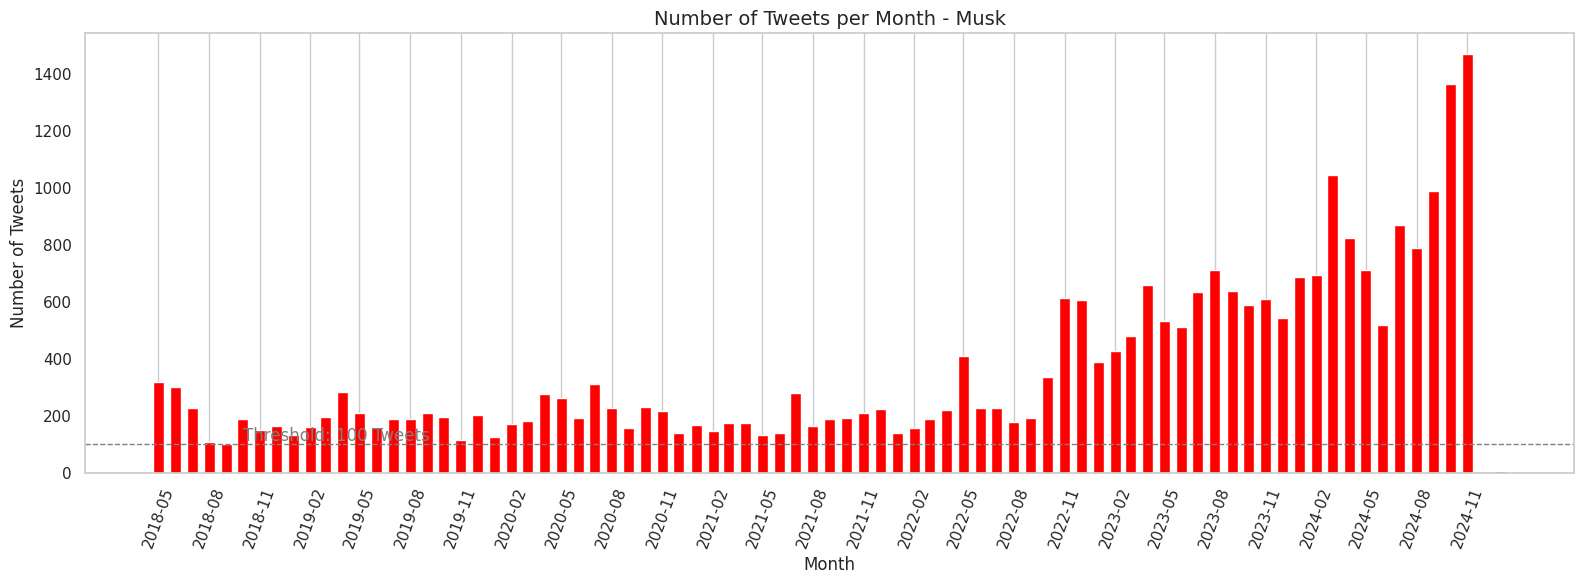

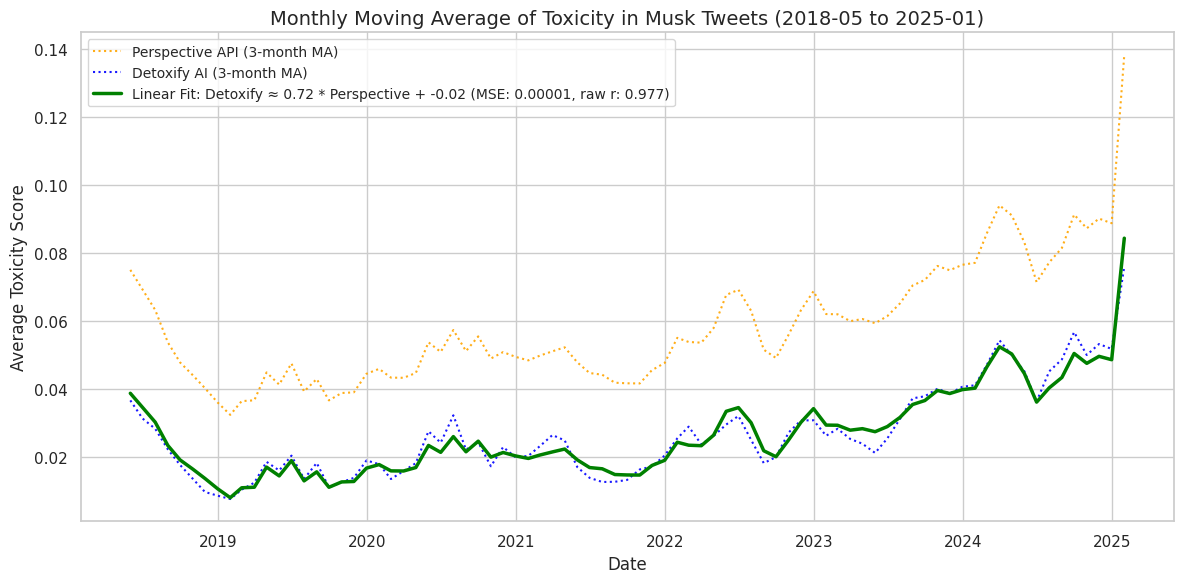

In [221]:
plot_tweet_analysis(merged_musk, person_name="Musk", start_date="2018-05-01", end_date="2025-01-10", tweet_threshold=100)

In [ ]:
# Define the LLM-style classifier function using detox score as input
def llm_full_classify(text: str, date: str, toxicity_score: float) -> Tuple[str, str, str]:
    text_lower = str(text).lower()
    year = pd.to_datetime(date).year if pd.notnull(date) else 2020

    # Defaults
    topic = "Undecided"
    ideology = "None"
    target = "None"

    # --- Topic Category ---
    if any(kw in text_lower for kw in ["tesla", "model s", "gigafactory", "supercharger"]):
        topic = "Tesla/EVs"
    elif any(kw in text_lower for kw in ["spacex", "mars", "rocket", "falcon"]):
        topic = "SpaceX/Space"
    elif any(kw in text_lower for kw in ["twitter", "x.com", "tweet", "shadowban", "free speech"]):
        topic = "Twitter/X"
    elif any(kw in text_lower for kw in ["ai", "neuralink", "openai", "machine learning"]):
        topic = "Tech/AI"
    elif any(kw in text_lower for kw in ["market", "stock", "sec", "fed", "inflation", "economy"]):
        topic = "Business/Markets"
    elif any(kw in text_lower for kw in ["biden", "trump", "senate", "election", "congress"]):
        topic = "Politics"
    elif any(kw in text_lower for kw in ["journalist", "cnn", "nyt", "mainstream media", "fake news"]):
        topic = "Media Criticism"
    elif any(kw in text_lower for kw in ["vacation", "dog", "philosophy", "life advice", "dating"]):
        topic = "Personal/Lifestyle"
    elif any(kw in text_lower for kw in ["bitcoin", "dogecoin", "crypto", "blockchain"]):
        topic = "Cryptocurrency"
    elif any(kw in text_lower for kw in ["woke", "cancel culture", "pronouns", "diversity", "identity politics"]):
        topic = "Culture Wars"
    elif any(kw in text_lower for kw in ["climate", "carbon", "solar", "renewable", "green energy"]):
        topic = "Climate/Energy"

    # --- Ideology Signal ---
    if any(kw in text_lower for kw in ["freedom", "regulation", "liberty", "censorship"]):
        ideology = "Libertarian"
    elif any(kw in text_lower for kw in ["biden", "liberal", "progressive"]):
        ideology = "Right-Leaning"
    elif any(kw in text_lower for kw in ["trump", "deep state", "election fraud"]):
        ideology = "Far-Right"
    elif any(kw in text_lower for kw in ["future", "ai", "sustainability", "interplanetary"]):
        ideology = "Tech-Progressive"
    elif year < 2016:
        ideology = "Pre-Political"

    # --- Toxicity Target (only if score high enough) ---
    if toxicity_score > 0.6:
        if any(kw in text_lower for kw in ["fake news", "journalist", "cnn", "nyt"]):
            target = "Media"
        elif any(kw in text_lower for kw in ["regulation", "government", "bureaucrat"]):
            target = "Government/Regulation"
        elif any(kw in text_lower for kw in ["woke", "diversity", "inclusion", "pronoun"]):
            target = '"Woke" Culture'
        elif any(kw in text_lower for kw in ["liberal", "leftist", "democrat"]):
            target = "Political Left"
        elif any(kw in text_lower for kw in ["maga", "republican", "right-wing"]):
            target = "Political Right"
        elif any(kw in text_lower for kw in ["gm", "ford", "competitor", "rival"]):
            target = "Competitors"
        elif any(kw in text_lower for kw in ["troll", "hater", "critic"]):
            target = "Critics"
        else:
            target = "Other"

    return topic, ideology, target

# Apply to full dataset (will take some time)
musk_detox[['topic_category', 'ideology_signal', 'toxicity_target']] = musk_detox.apply(
    lambda row: pd.Series(llm_full_classify(row['clean_text'], row['date'], row['toxicity'])),
    axis=1
)

# Save to CSV
output_path = "musk_categorized_llm.csv"
musk_detox.to_csv(output_path, index=False)

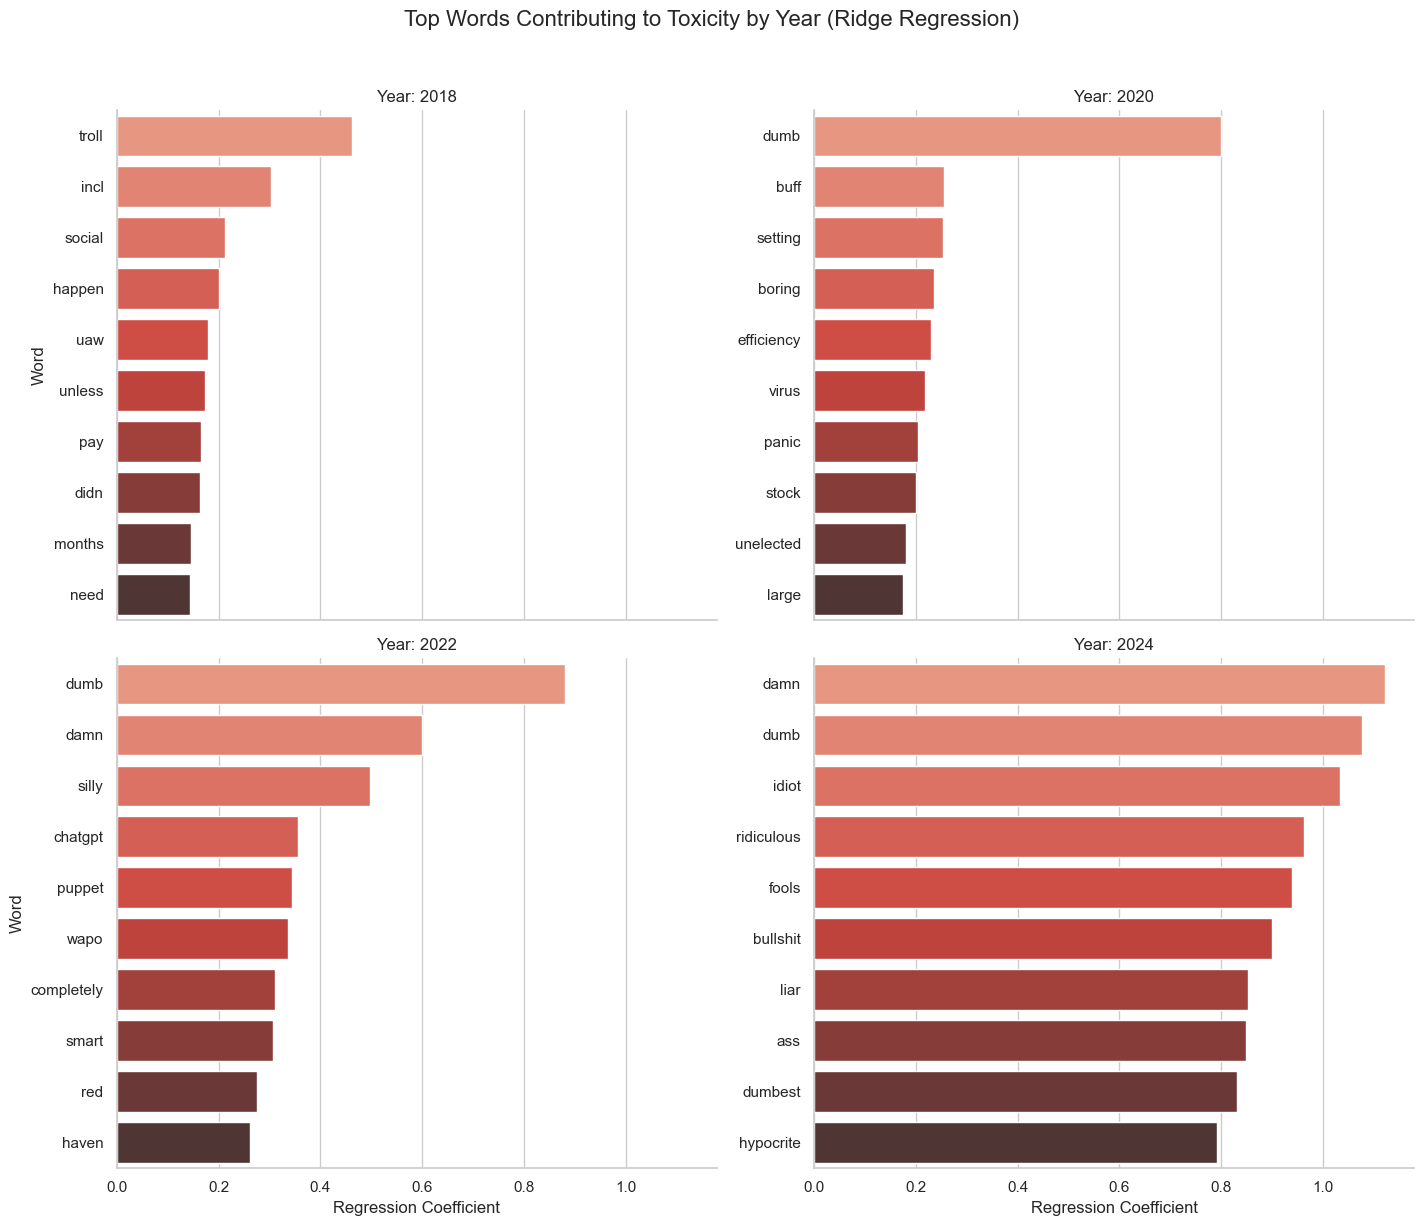

In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

X = merged_musk['clean_text']  # your text data
y = merged_musk['detox_toxicity']  # Perspective or Detoxify score

vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
X_vec = vectorizer.fit_transform(X)

model = Ridge(alpha=1.0)
model.fit(X_vec, y)

# Inspect word contributions
coefficients = model.coef_
features = vectorizer.get_feature_names_out()
top_words = sorted(zip(features, coefficients), key=lambda x: -abs(x[1]))[:30]

top_words_df = pd.DataFrame(top_words, columns=['word', 'coefficient'])
top_words_df['contribution'] = top_words_df['coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
top_words_df['coefficient'] = top_words_df['coefficient'].abs()
top_words_df = top_words_df.sort_values(by='coefficient', ascending=False)

# Make sure your 'date' column is datetime
merged_musk['date'] = pd.to_datetime(merged_musk['date'], errors='coerce')
merged_musk = merged_musk.dropna(subset=['clean_text', 'detox_toxicity', 'date'])
merged_musk['year'] = merged_musk['date'].dt.year

# Define the years of interest
years = [2018, 2020, 2022, 2024]
top_words_by_year = []

for year in years:
    subset = merged_musk[merged_musk['year'] == year]
    if len(subset) < 20:
        continue  # skip sparse years

    X = subset['clean_text']
    y = subset['detox_toxicity']

    vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
    X_vec = vectorizer.fit_transform(X)

    model = Ridge(alpha=1.0)
    model.fit(X_vec, y)

    coefficients = model.coef_
    features = vectorizer.get_feature_names_out()
    
    # Get top 10 positive contributors
    top_indices = coefficients.argsort()[-10:][::-1]
    top_words = [(features[i], coefficients[i]) for i in top_indices]

    df_top = pd.DataFrame(top_words, columns=['word', 'coefficient'])
    df_top['year'] = year
    top_words_by_year.append(df_top)

# Combine results
df_all_years = pd.concat(top_words_by_year, ignore_index=True)

# Create facetgrid by year
sns.set(style="whitegrid")
g = sns.FacetGrid(
    df_all_years, 
    col="year", 
    col_wrap=2,
    height=6, 
    aspect=1.2,
    sharey=False
)

# Map the barplot to each facet
g.map_dataframe(
    sns.barplot,
    x="coefficient", 
    y="word", 
    palette="Reds_d"
)

# Add titles and labels
g.set_axis_labels("Regression Coefficient", "Word")
g.set_titles("Year: {col_name}")
g.fig.suptitle("Top Words Contributing to Toxicity by Year (Ridge Regression)", 
               fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

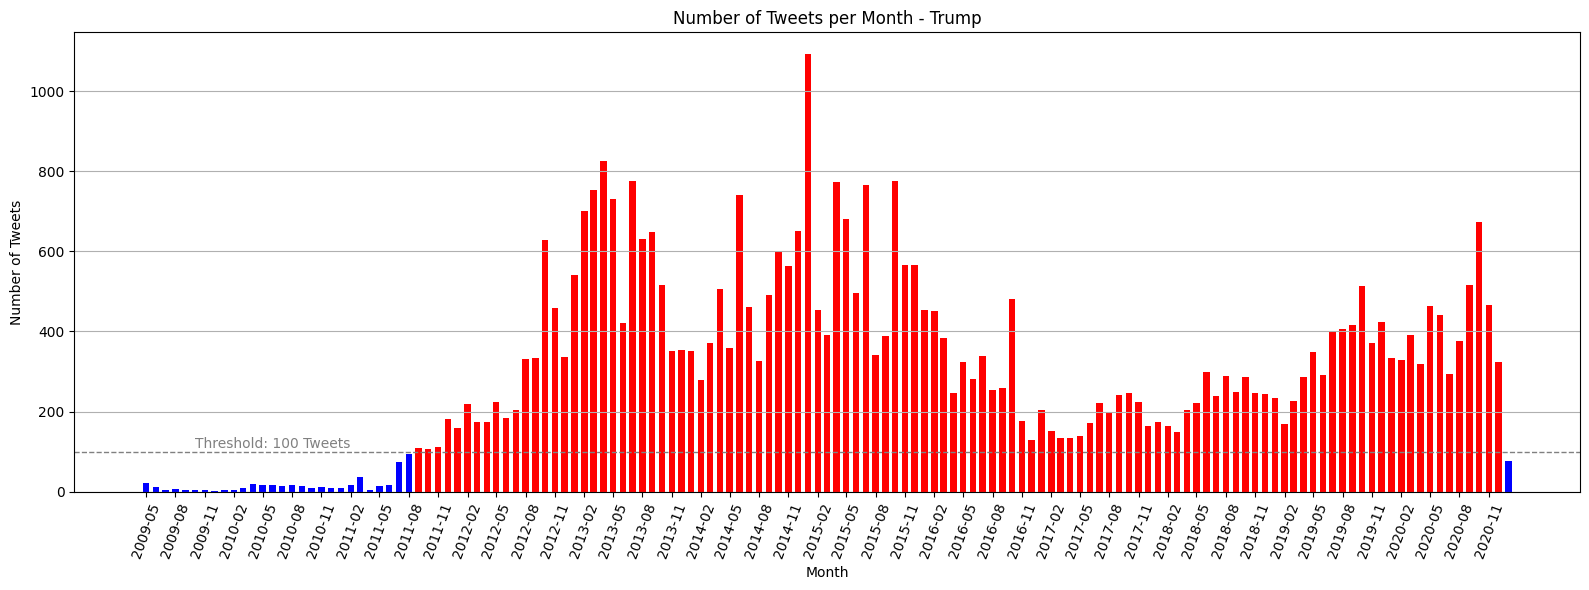

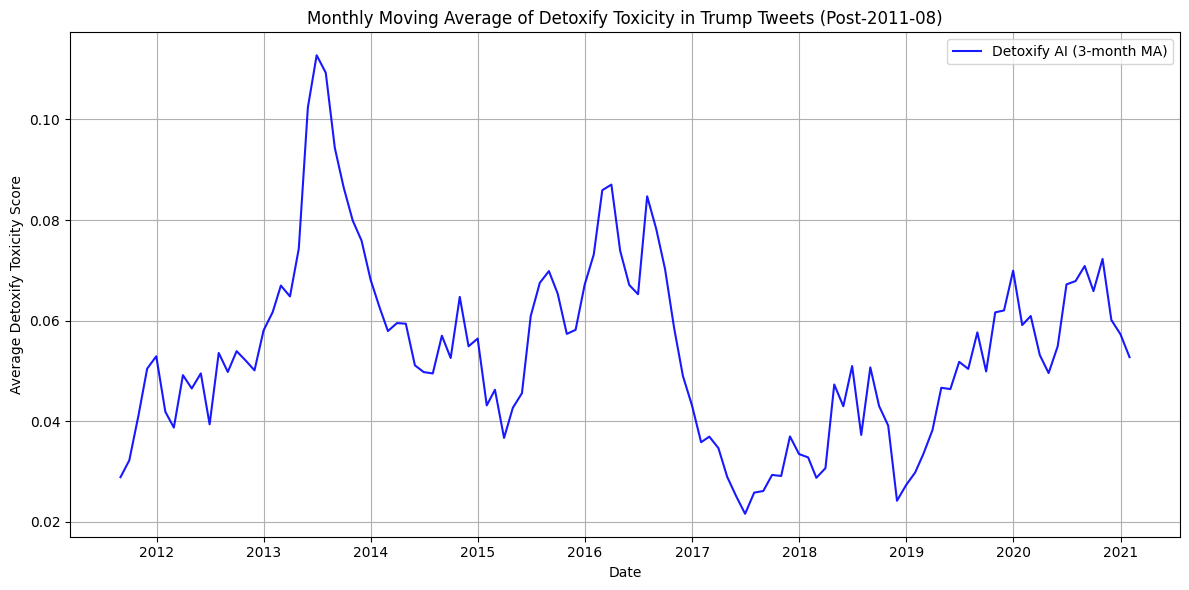

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- Load Data ---
trump_df = merged_trump.copy()

# --- Preprocessing ---
trump_df['date'] = pd.to_datetime(trump_df['date'], errors='coerce')
trump_df = trump_df.dropna(subset=['date'])
trump_df.set_index('date', inplace=True)

# --- Parameters ---
tweet_threshold = 100
start_date = "2011-08-01"
person_name = "Trump"

# --- Plot 1: Monthly Tweet Count ---
trump_df['month'] = trump_df.index.to_period('M').to_timestamp()
monthly_counts = trump_df.groupby('month').size()
colors = ['red' if count > tweet_threshold else 'blue' for count in monthly_counts]

plt.figure(figsize=(16, 6))
plt.bar(monthly_counts.index, monthly_counts.values, color=colors, width=20)
plt.axhline(tweet_threshold, color='gray', linestyle='--', linewidth=1)
if len(monthly_counts.index) > 5:
    plt.text(monthly_counts.index[5], tweet_threshold + 10, f'Threshold: {tweet_threshold} Tweets', color='gray')
plt.title(f"Number of Tweets per Month - {person_name}")
plt.xlabel("Month")
plt.ylabel("Number of Tweets")
plt.grid(axis='y')
ax = plt.gca()
ax.set_xticks(monthly_counts.index[::3])
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_counts.index[::3]], rotation=70)
plt.tight_layout()
plt.show()

# --- Plot 2: Monthly Rolling Averages of Detoxify Scores ---
df_filtered = trump_df[trump_df.index >= start_date]
monthly_avg_detox = df_filtered.resample('ME')[['detox_toxicity', 'detox_severe_toxicity', 'detox_insult', 'detox_identity_attack']].mean()
rolling_avg_detox = monthly_avg_detox.rolling(window=3, min_periods=1).mean()

# --- Plot Detoxify Toxicity Over Time ---
plt.figure(figsize=(12, 6))
plt.plot(rolling_avg_detox.index,
         rolling_avg_detox['detox_toxicity'],
         label='Detoxify AI (3-month MA)', color='blue', linestyle='-', alpha=0.9)

plt.title(f"Monthly Moving Average of Detoxify Toxicity in {person_name} Tweets (Post-{start_date[:7]})")
plt.xlabel("Date")
plt.ylabel("Average Detoxify Toxicity Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


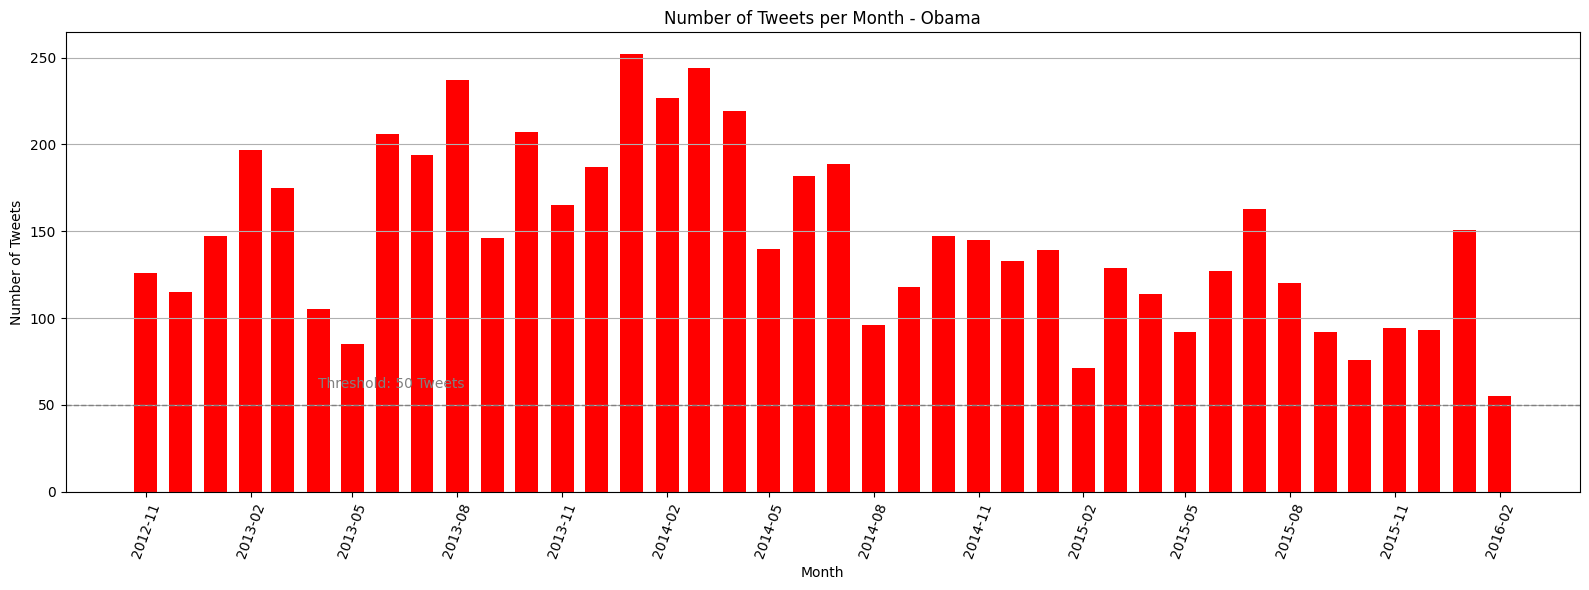

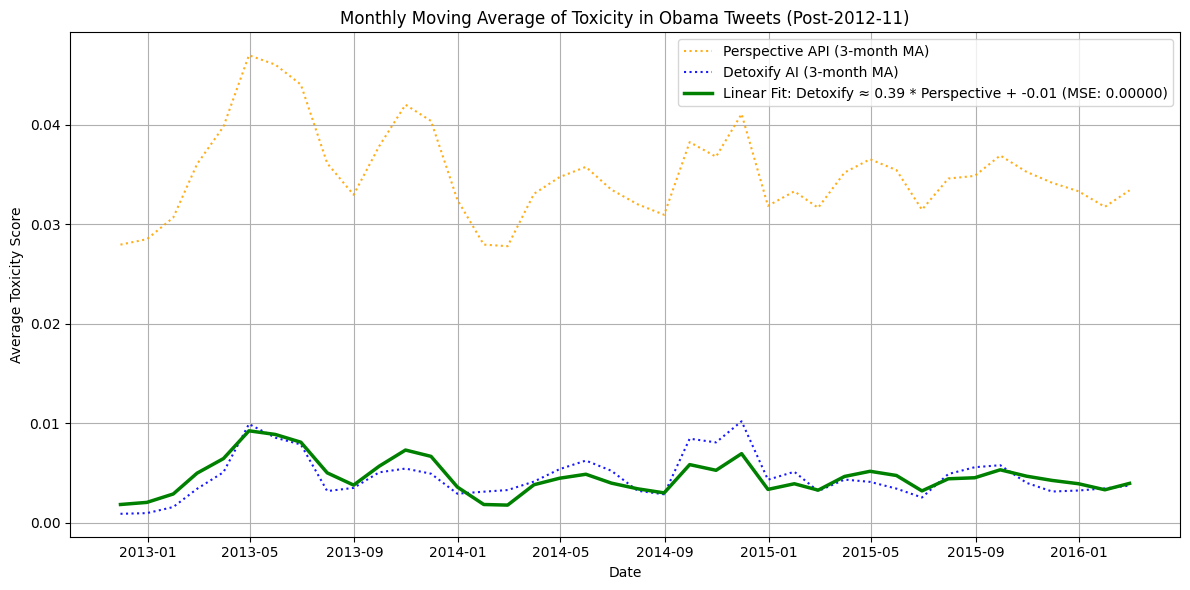

In [123]:
plot_tweet_analysis(merged_obama, person_name="Obama", start_date="2012-11-01", tweet_threshold=50)

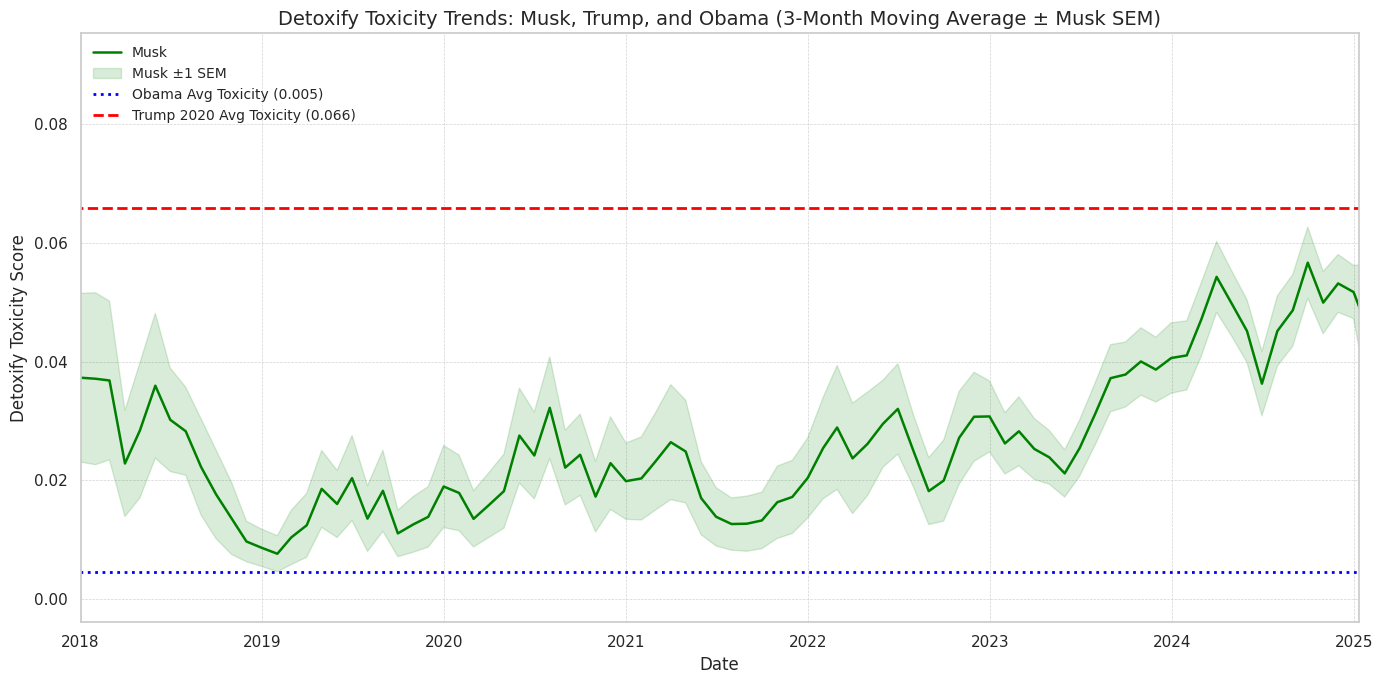

In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Apply clean plot style
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

# Convert columns to numeric before any operations
# Ensure detox_toxicity columns are numeric in all dataframes
for df in [merged_musk, merged_trump, merged_obama]:
    if 'detox_toxicity' in df.columns:
        df['detox_toxicity'] = pd.to_numeric(df['detox_toxicity'], errors='coerce')
    
    # Make sure date is properly set as datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df.set_index('date', inplace=True)

# === Calculate Monthly Averages first, then apply 3-month rolling ===
# Use 'ME' for month end as recommended in warning messages
musk_monthly = merged_musk['detox_toxicity'].resample('ME').mean()
trump_monthly = merged_trump['detox_toxicity'].resample('ME').mean()
obama_monthly = merged_obama['detox_toxicity'].resample('ME').mean()

# Calculate 3-month rolling averages (window=3)
musk_rolling = musk_monthly.rolling(window=3, min_periods=1).mean()
trump_rolling = trump_monthly.rolling(window=3, min_periods=1).mean()
obama_rolling = obama_monthly.rolling(window=3, min_periods=1).mean()

# Calculate SEM for Musk data
musk_count = merged_musk['detox_toxicity'].resample('ME').count()
musk_std = merged_musk['detox_toxicity'].resample('ME').std()
musk_sem = musk_std / np.sqrt(musk_count)
musk_sem_rolling = musk_sem.rolling(window=3, min_periods=1).mean()

# === Plotting Setup ===
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Musk toxicity + SEM
ax.plot(musk_rolling.index, musk_rolling.values, label='Musk', color='green', linewidth=1.8)
ax.fill_between(musk_rolling.index,
                musk_rolling.values - musk_sem_rolling.values,
                musk_rolling.values + musk_sem_rolling.values,
                color='green', alpha=0.15, label='Musk ±1 SEM')

# Plot Trump and Obama lines (faded)
#ax.plot(trump_rolling.index, trump_rolling.values, label='Trump', color='red', linewidth=1.8, alpha=0.25)
#ax.plot(obama_rolling.index, obama_rolling.values, label='Obama', color='blue', linewidth=1.8, alpha=0.25)

# === Average Lines ===
# Obama average
obama_avg = obama_rolling.dropna().mean()
ax.hlines(y=obama_avg, xmin=pd.Timestamp('2011-01-01'), xmax=pd.Timestamp('2025-12-31'),
          color='blue', linestyle=':', linewidth=2, label=f"Obama Avg Toxicity ({obama_avg:.3f})")

# Trump 2020 average
trump_2020_window = trump_rolling['2020-06-01':'2021-01-08'].dropna()
trump_2020_avg = trump_2020_window.mean()
ax.hlines(y=trump_2020_avg, xmin=pd.Timestamp('2011-01-01'), xmax=pd.Timestamp('2025-12-31'),
          color='red', linestyle='--', linewidth=2, label=f"Trump 2020 Avg Toxicity ({trump_2020_avg:.3f})")

# === Final Touches ===
ax.set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2025-01-10'))
ax.set_title("Detoxify Toxicity Trends: Musk, Trump, and Obama (3-Month Moving Average ± Musk SEM)")
ax.set_xlabel("Date")
ax.set_ylabel("Detoxify Toxicity Score")
ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/2692747750.py:10: DtypeWarning: Columns (12,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("musk_categorized_llm.csv", parse_dates=["date"])


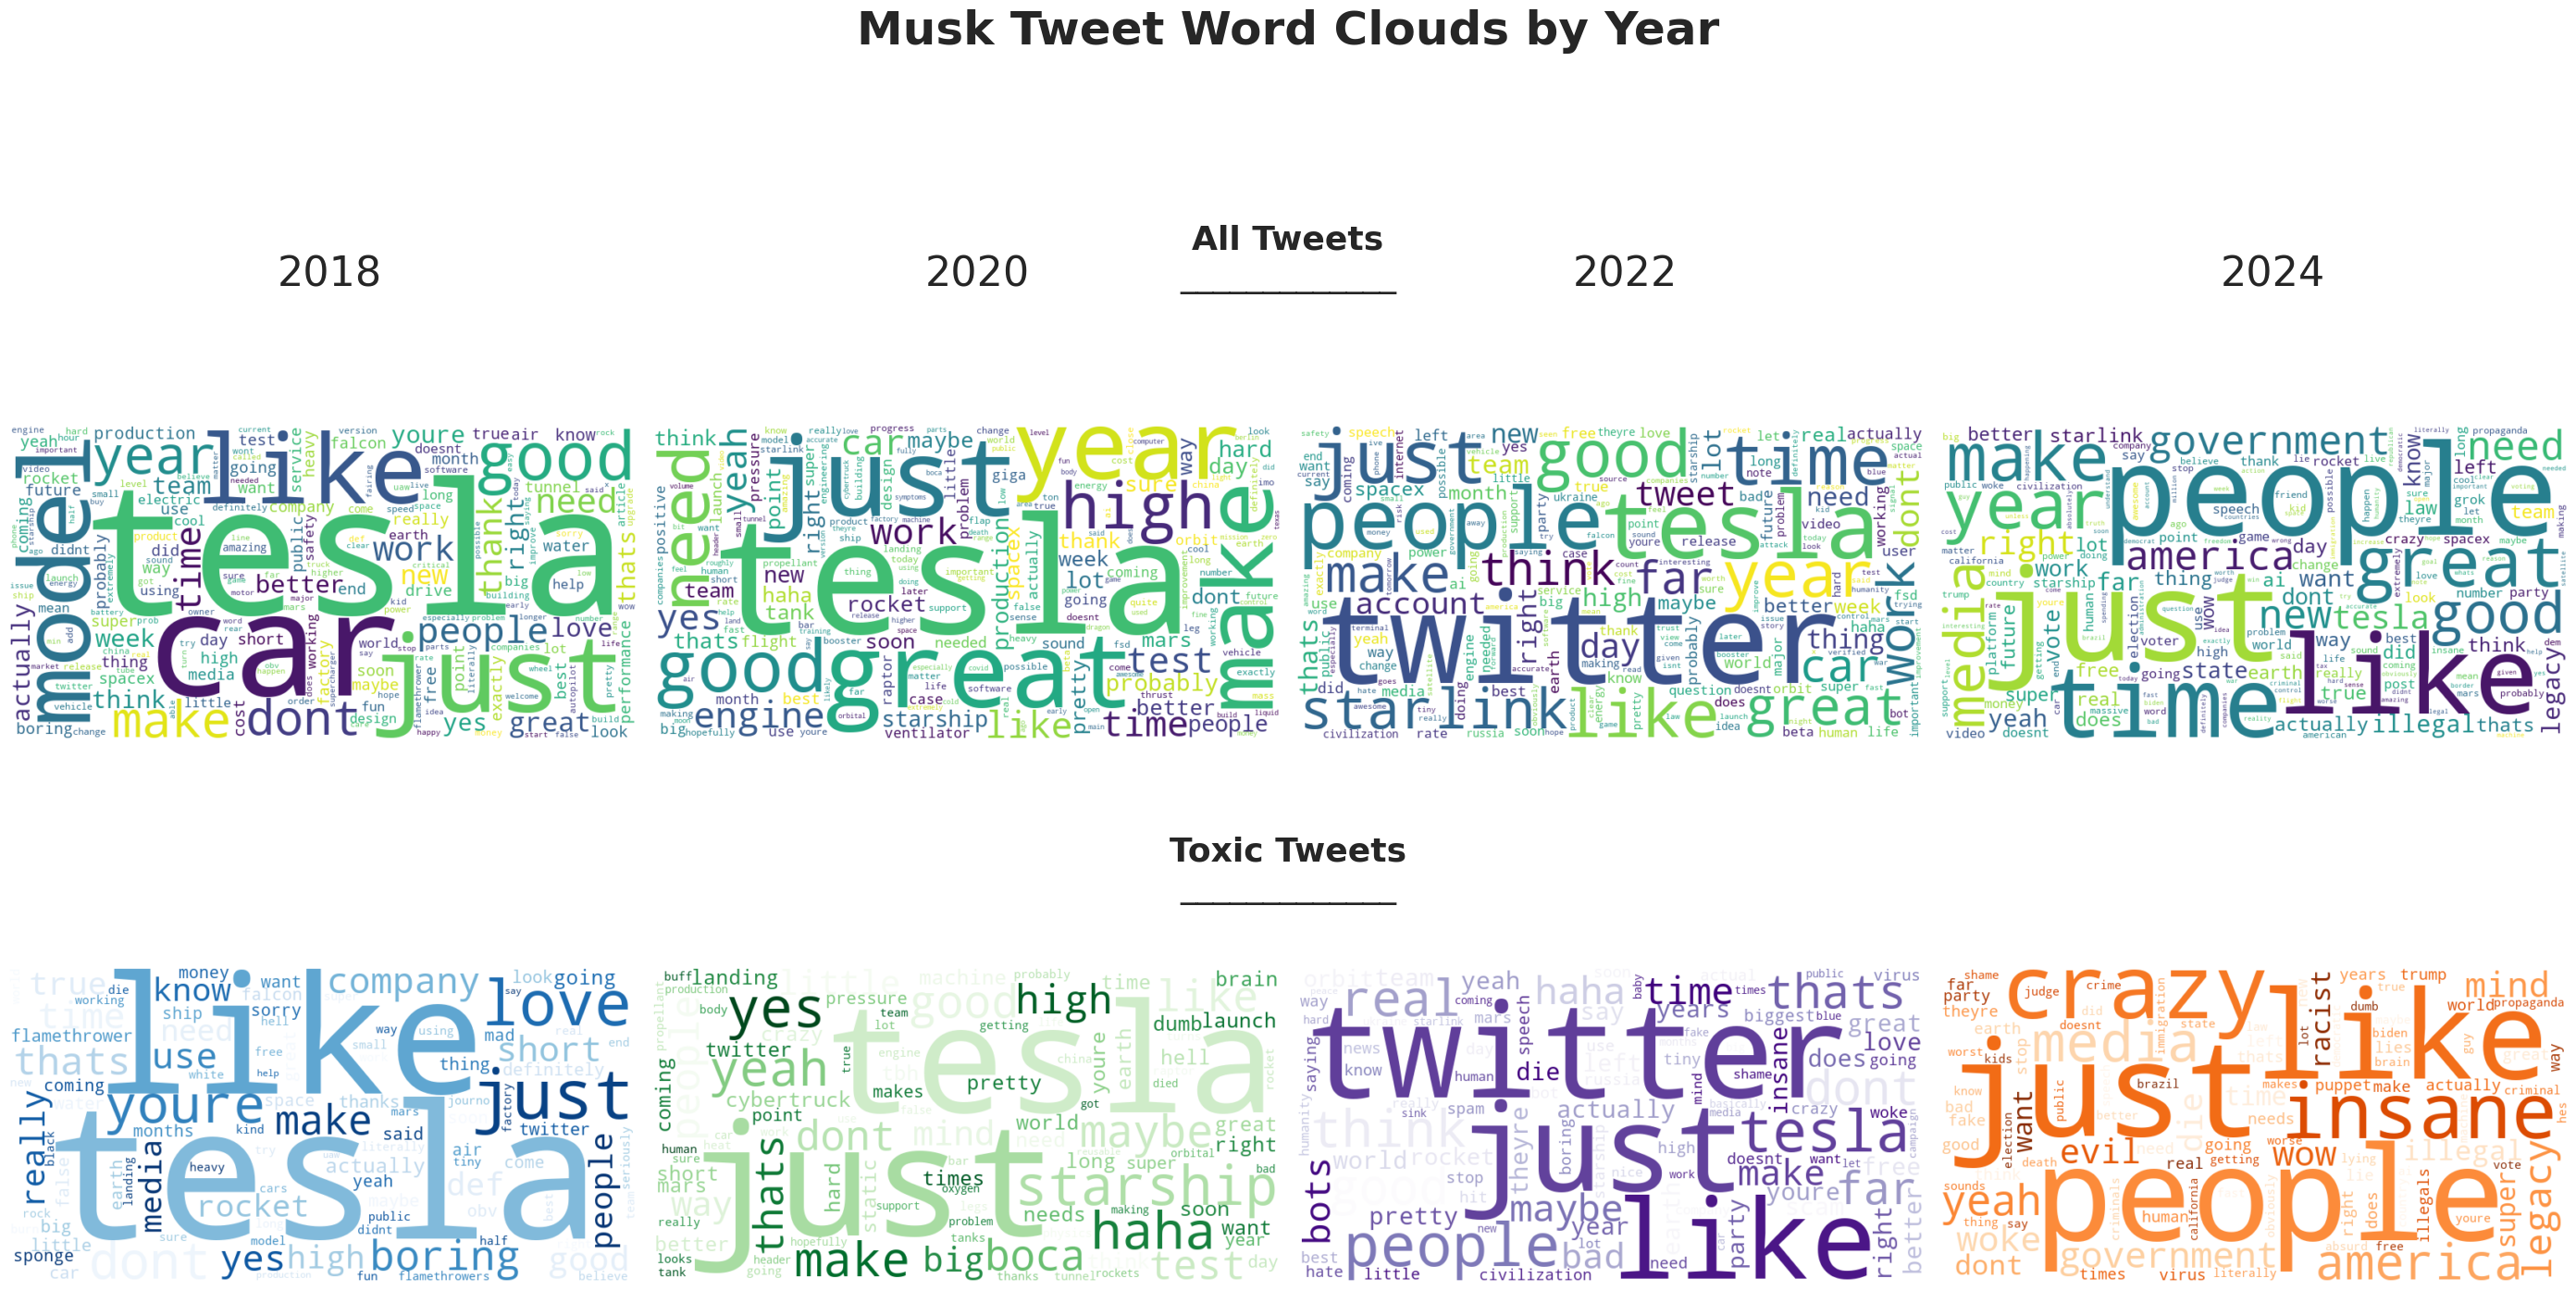

In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import emoji
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# === Load Data ===
df = pd.read_csv("musk_categorized_llm.csv", parse_dates=["date"])
df = df.dropna(subset=['text', 'toxicity'])

# === Text Cleaning ===
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"&\w+;", '', text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    keep_short = {'ai', 'ev', 'x'}
    text = ' '.join([word for word in text.split() if len(word) > 2 or word in keep_short])
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_text)

# === Stopwords ===
stopwords = list(ENGLISH_STOP_WORDS) + ['amp', 'https', 'rt', 'im', 'elon', 'musk', 'get', 'one', 'would']

# === Setup ===
years = [2018, 2020, 2022, 2024]
colors = ['Blues', 'Greens', 'Purples', 'Oranges']

# === TF-IDF Word Cloud ===
def tfidf_wordcloud(texts, ax, cmap='Blues'):
    if not texts:
        ax.axis('off')
        return
    vectorizer = TfidfVectorizer(stop_words=stopwords, max_features=100)
    X = vectorizer.fit_transform(texts)
    tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate_from_frequencies(tfidf_scores)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')

# === Plotting ===
fig, axs = plt.subplots(2, 4, figsize=(28, 20))
axs = axs.flatten()

for i, year in enumerate(years):
    year_df = df[df['date'].dt.year == year]

    # --- All Tweets ---
    all_text = " ".join(year_df['clean_text'].values)
    wc_all = WordCloud(width=800, height=400, background_color='white',
                       stopwords=stopwords, collocations=False).generate(all_text)
    axs[i].imshow(wc_all, interpolation='bilinear')
    axs[i].axis('off')

    # --- Toxic Tweets ---
    tox_threshold = year_df['toxicity'].quantile(0.75)
    toxic_texts = year_df[year_df['toxicity'] >= tox_threshold]['clean_text'].tolist()
    tfidf_wordcloud(toxic_texts, axs[i + 4], cmap=colors[i])

# === Labels and Layout ===
fig.suptitle("Musk Tweet Word Clouds by Year", fontsize=36, weight='bold', y=.9)

# Underlined Section Titles
fig.text(0.5, 0.77, "All Tweets", ha='center', fontsize=26, weight='bold', style='normal')
fig.text(0.5, 0.44, "Toxic Tweets", ha='center', fontsize=26, weight='bold', style='normal')
fig.text(0.5, 0.75, "_____________", ha='center', fontsize=26)
fig.text(0.5, 0.42, "_____________", ha='center', fontsize=26)

# Year Labels (top only)
x_positions = [0.13, 0.38, 0.63, 0.88]
for xpos, year in zip(x_positions, years):
    fig.text(xpos, 0.75, str(year), ha='center', fontsize=32)

plt.tight_layout(rect=[0, 0.03, 1, 0.89])
plt.show()


In [189]:
df

,Unnamed: 0,id,url,twitterUrl,text,retweetCount,replyCount,likeCount,quoteCount,viewCount,...,toxicity,severe_toxicity,obscene,identity_attack,insult,threat,sexual_explicit,topic_category,ideology_signal,toxicity_target
0,9303,15434727182,https://x.com/elonmusk/status/15434727182,https://twitter.com/elonmusk/status/15434727182,"Please ignore prior tweets, as that was someon...",697.0,1422.0,6392.0,400.0,NaN,...,0.000631,0.000002,0.000024,0.000065,0.000296,0.000020,0.000017,Twitter/X,Pre-Political,NaN
1,9302,142179928203460608,https://x.com/elonmusk/status/142179928203460608,https://twitter.com/elonmusk/status/1421799282...,Went to Iceland on Sat to ride bumper cars on ...,27.0,40.0,197.0,9.0,NaN,...,0.000380,0.000002,0.000023,0.000063,0.000154,0.000027,0.000014,Undecided,Pre-Political,NaN
2,9301,142188458125963264,https://x.com/elonmusk/status/142188458125963264,https://twitter.com/elonmusk/status/1421884581...,I made the volume on the Model S http://t.co/w...,19.0,43.0,124.0,8.0,NaN,...,0.000282,0.000003,0.000021,0.000042,0.000133,0.000022,0.000017,Tesla/EVs,Pre-Political,NaN
3,9300,142880871391838208,https://x.com/elonmusk/status/142880871391838208,https://twitter.com/elonmusk/status/1428808713...,"Great Voltaire quote, arguably better than Twa...",36.0,31.0,87.0,7.0,NaN,...,0.001015,0.000003,0.000021,0.000038,0.000515,0.000047,0.000028,Tech/AI,Tech-Progressive,NaN
4,9299,142881284019060736,https://x.com/elonmusk/status/142881284019060736,https://twitter.com/elonmusk/status/1428812840...,That was a total non sequitur btw,12.0,42.0,133.0,9.0,NaN,...,0.001260,0.000002,0.000042,0.000117,0.000567,0.000027,0.000026,Undecided,Pre-Political,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36606,46000,1903001906676482555,https://x.com/elonmusk/status/1903001906676482555,https://twitter.com/elonmusk/status/1903001906...,@gatewaypundit Are they all secret buddies?,1412.0,808.0,10384.0,68.0,746250.0,...,0.001372,0.000004,0.000058,0.000053,0.000837,0.000104,0.000054,Business/Markets,NaN,NaN
36607,45997,1903148848685679068,https://x.com/elonmusk/status/1903148848685679068,https://twitter.com/elonmusk/status/1903148848...,The ultimate master plan of @Tesla is to creat...,12933.0,7955.0,111498.0,831.0,29754653.0,...,0.000420,0.000002,0.000020,0.000068,0.000160,0.000041,0.000019,Tech/AI,Tech-Progressive,NaN
36608,45993,1903150113175863485,https://x.com/elonmusk/status/1903150113175863485,https://twitter.com/elonmusk/status/1903150113...,It’s so real 🤣🤣 https://t.co/f0nyUCe6ES,17619.0,9200.0,139458.0,940.0,29953040.0,...,0.000643,0.000002,0.000024,0.000109,0.000269,0.000033,0.000023,Undecided,NaN,NaN
36609,45983,1903228023345651900,https://x.com/elonmusk/status/1903228023345651900,https://twitter.com/elonmusk/status/1903228023...,The worst bad guys are the ones who are financ...,35378.0,12367.0,220002.0,1405.0,35474542.0,...,0.141620,0.000009,0.000705,0.005076,0.071626,0.001452,0.000200,Tesla/EVs,Tech-Progressive,NaN


/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/3089840612.py:7: DtypeWarning: Columns (12,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  musk_classify = pd.read_csv("musk_categorized_llm.csv", parse_dates=["date"])


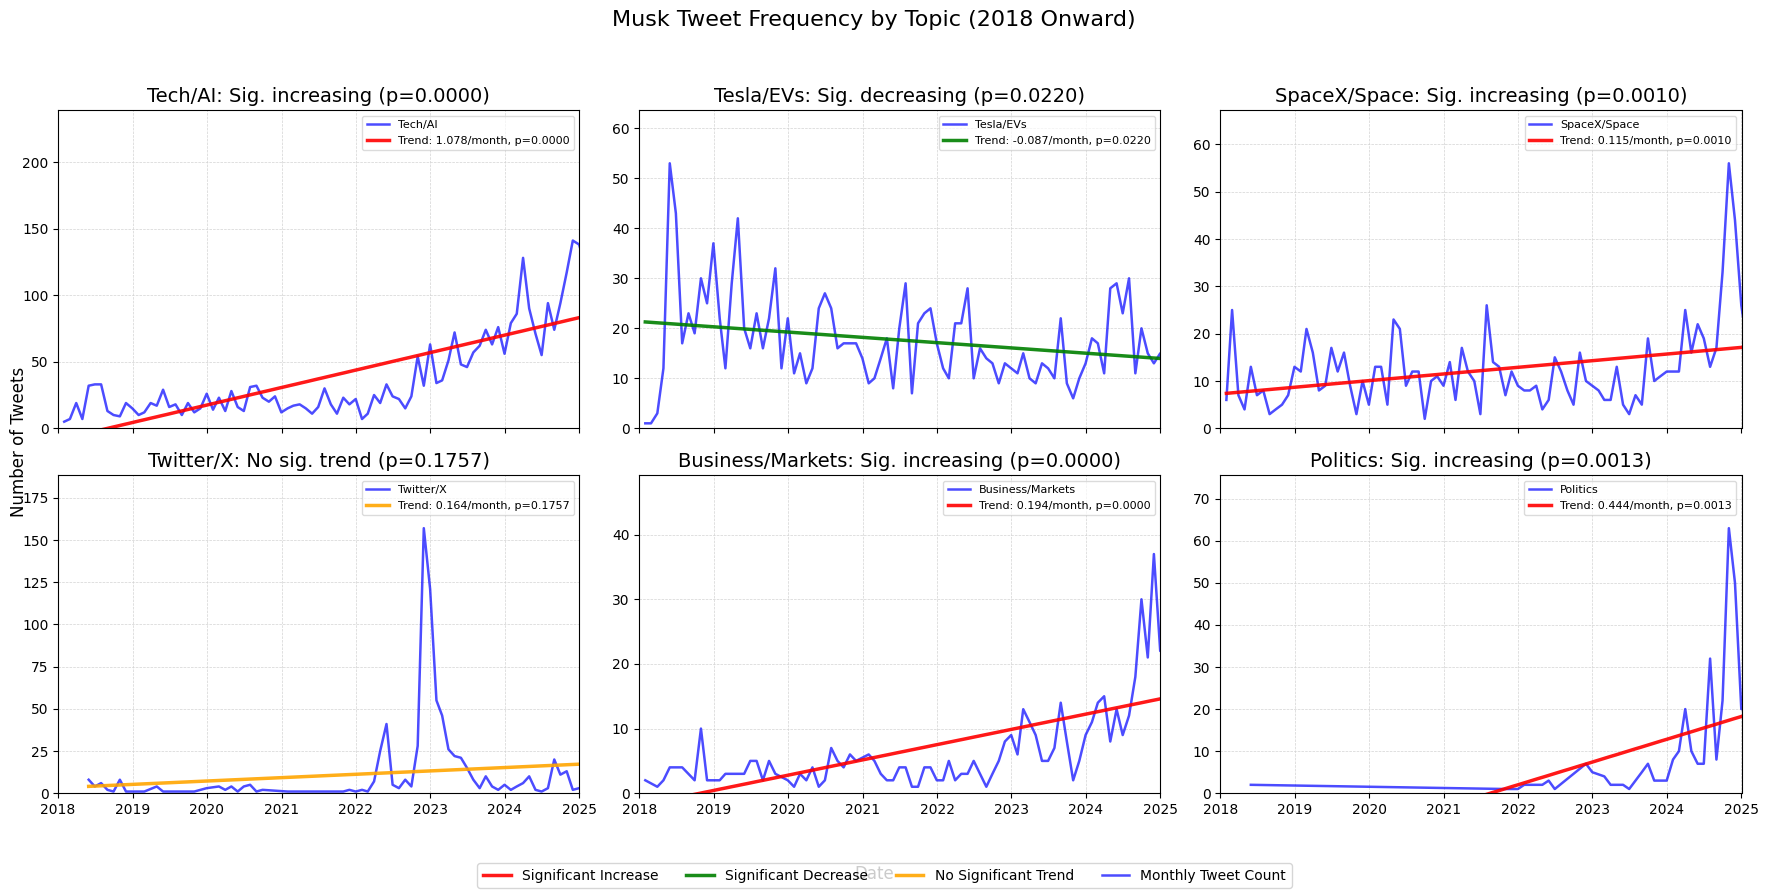

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data
musk_classify = pd.read_csv("musk_categorized_llm.csv", parse_dates=["date"])

# Ensure required fields are present and clean
musk_classify = musk_classify.dropna(subset=['topic_category', 'date'])
musk_classify.set_index('date', inplace=True)

# Filter data from 2018 onward and exclude "Undecided"
musk_classify = musk_classify[
    (musk_classify['topic_category'] != 'Undecided') &
    (musk_classify.index >= '2018-01-01')
]

# Set plot style
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.formatter.useoffset'] = False

# Group by month and topic to get frequency (count)
monthly_topic_counts = (
    musk_classify
    .groupby(['topic_category', pd.Grouper(freq='M')])
    .size()
    .reset_index(name='count')
)

# Find top 6 most common topics
top_topics = musk_classify['topic_category'].value_counts().nlargest(6).index.tolist()
monthly_topic_counts = monthly_topic_counts[monthly_topic_counts['topic_category'].isin(top_topics)]

# Prepare figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9), sharex=True, sharey=False)
axes = axes.flatten()

# Function to convert dates to numeric for regression
def date_to_numeric(dates):
    return np.array([(d - np.datetime64('2018-01-01')).astype(int) / (1e9 * 60 * 60 * 24 * 30) for d in dates])

# Plot each topic
for ax, topic in zip(axes, top_topics):
    # Get topic-specific data
    topic_data = monthly_topic_counts[monthly_topic_counts['topic_category'] == topic]
    dates = topic_data['date'].values
    counts = topic_data['count'].values.astype(float)
    
    # Find y-limits with some padding
    if len(counts) > 0:
        y_min = 0
        y_max = np.max(counts) * 1.2  # 20% padding
    else:
        y_min, y_max = 0, 5  # Default
    
    # Plot counts
    ax.plot(dates, counts, label=topic, color='blue', linewidth=1.8, alpha=0.7)
    
    # Linear regression if enough points
    if len(dates) > 2:
        x_numeric = date_to_numeric(dates)
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_numeric, counts)
        
        # Regression line
        x_range = np.linspace(x_numeric.min(), x_numeric.max(), 100)
        y_range = intercept + slope * x_range
        date_range = [np.datetime64('2018-01-01') + np.timedelta64(int(x * 30), 'D') for x in x_range]
        
        # Significant?
        is_significant = p_value < 0.05
        trend_direction = "increasing" if slope > 0 else "decreasing"
        
        # Color coding
        reg_color = 'red' if slope > 0 and is_significant else 'green' if slope < 0 and is_significant else 'orange'
        ax.plot(date_range, y_range, color=reg_color, linewidth=2.5, alpha=0.9, 
                label=f"Trend: {slope:.3f}/month, p={p_value:.4f}")
        
        # Title annotation
        if is_significant:
            sig_text = f"Sig. {trend_direction} (p={p_value:.4f})"
        else:
            sig_text = f"No sig. trend (p={p_value:.4f})"
        title = f"{topic}: {sig_text}"
    else:
        title = f"{topic}: Insufficient data for trend"
    
    ax.set_title(title)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
    ax.legend(loc='upper right', frameon=True, framealpha=0.7, fontsize=8)

# X-axis formatting
for ax in axes:
    ax.set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2025-01-01'))

# Figure labels
fig.suptitle("Musk Tweet Frequency by Topic (2018 Onward)", fontsize=16)
fig.supxlabel("Date")
fig.supylabel("Number of Tweets")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Legend for regression colors
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='red', lw=2.5, alpha=0.9),
    Line2D([0], [0], color='green', lw=2.5, alpha=0.9),
    Line2D([0], [0], color='orange', lw=2.5, alpha=0.9),
    Line2D([0], [0], color='blue', lw=1.8, alpha=0.7),
]
fig.legend(custom_lines, 
           ['Significant Increase', 'Significant Decrease', 'No Significant Trend', 'Monthly Tweet Count'],
           loc='lower center', ncol=4, frameon=True, fontsize=10)

plt.show()


/var/folders/v_/7gz326qj5hv0nz696tx9yb1h0000gn/T/ipykernel_49890/2452284229.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')


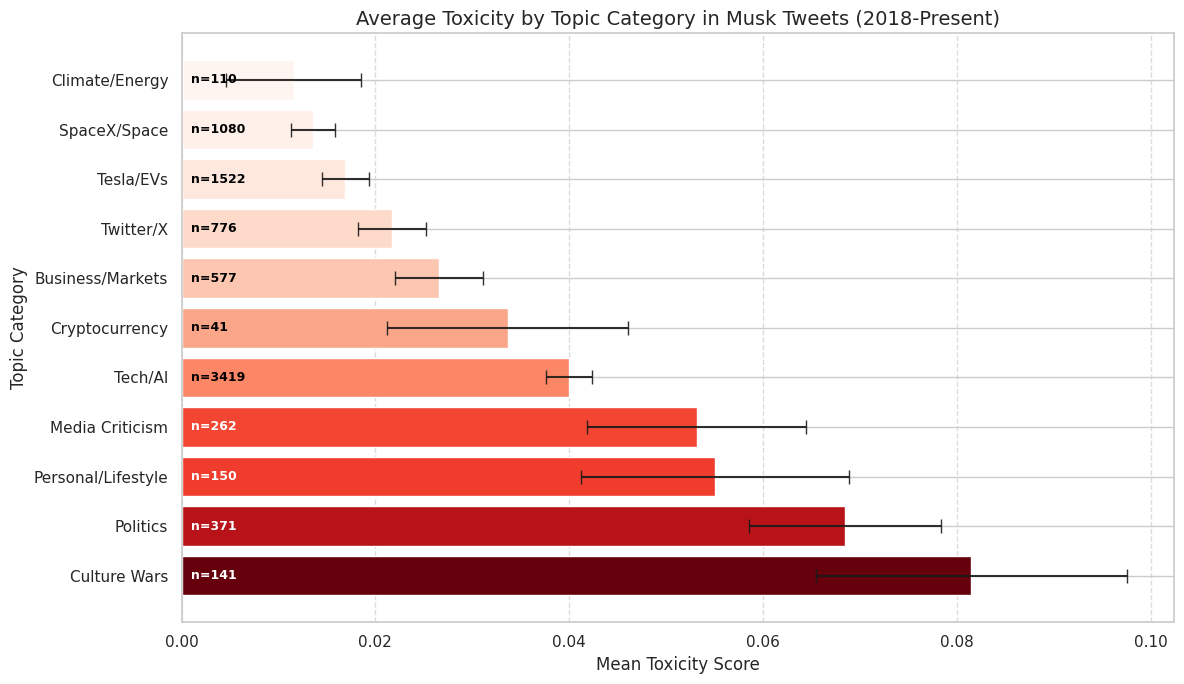

In [226]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize, TwoSlopeNorm

# Normalize the mean toxicity
norm = Normalize(topic_toxicity['mean'].min(), topic_toxicity['mean'].max())

# Truncate Reds colormap to avoid very light colors
cmap = cm.get_cmap('Reds')
truncated_cmap = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create the figure
plt.figure(figsize=(12, 7))

# Bar colors based on toxicity mean
bar_colors = cmap(norm(topic_toxicity['mean']))

bars = plt.barh(
    topic_toxicity['topic_category'], 
    topic_toxicity['mean'],
    xerr=topic_toxicity['sem'], 
    capsize=5,
    color=bar_colors,
    error_kw={'alpha': 0.9}
)

# Add count labels with adaptive color
for i, (index, row) in enumerate(topic_toxicity.iterrows()):
    toxicity_val = row['mean']
    brightness = norm(toxicity_val)
    label_color = 'white' if brightness > 0.5 else 'black'
    plt.text(0.001, i, f'n={int(row["count"])}', va='center', fontsize=9, color=label_color, weight='bold')

# Titles and labels
plt.title('Average Toxicity by Topic Category in Musk Tweets (2018-Present)', fontsize=14)
plt.xlabel('Mean Toxicity Score', fontsize=12)
plt.ylabel('Topic Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [230]:
# Print the range of dates in obama, musk, and trump dataframes
print("Obama date range:", obama.date.min(), "to", obama.date.max())
print("Musk date range:", musk.date.min(), "to", musk.date.max())
print("Trump date range:", trump.date.min(), "to", trump.date.max())

Obama date range: 2012-11-05 22:07:00 to 2019-04-10 17:08:00
Musk date range: 2010-06-04 18:31:57+00:00 to 2025-03-21 23:57:08+00:00
Trump date range: 2009-05-04 00:00:00 to 2021-01-08 00:00:00


In [274]:
# Print the percentage of tweets kept from the orig dfs in the detox dfs
print(f"{len(obama_detox)} Obama tweets kept:", len(obama_detox) / len(obama_orig) * 100)
print(f"{len(musk_detox)} Musk tweets kept:", len(musk_detox) / len(musk_orig) * 100)
print(f"{len(trump_detox)} Trump tweets kept:", len(trump_detox) / len(trump_orig) * 100)


6754 Obama tweets kept: 98.58414829951832
36611 Musk tweets kept: 68.1299663174349
42491 Trump tweets kept: 75.11092255749412
